# Importing Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.linear_model import LogisticRegression

# Data Collection

### Load the Calories Dataset

In [2]:
# load the dataset
calories = pd.read_csv("/Users/macbookpro/Desktop/ML & DL & GENAI Projects/Diseases Predictive System/Calorie Burn Predictive System/data/calories.csv")
calories

,User_ID,Calories
0,14733363,231.0
1,14861698,66.0
2,11179863,26.0
3,16180408,71.0
4,17771927,35.0
...,...,...
14995,15644082,45.0
14996,17212577,23.0
14997,17271188,75.0
14998,18643037,11.0


In [3]:
# 5 rows of the dataset
calories.head()

,User_ID,Calories
0,14733363,231.0
1,14861698,66.0
2,11179863,26.0
3,16180408,71.0
4,17771927,35.0


### Load the Exercise Dataset

In [4]:
# exercise dataset
exercise_data = pd.read_csv("/Users/macbookpro/Desktop/ML & DL & GENAI Projects/Diseases Predictive System/Calorie Burn Predictive System/data/exercise.csv")
exercise_data

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8
...,...,...,...,...,...,...,...,...
14995,15644082,female,20,193.0,86.0,11.0,92.0,40.4
14996,17212577,female,27,165.0,65.0,6.0,85.0,39.2
14997,17271188,female,43,159.0,58.0,16.0,90.0,40.1
14998,18643037,male,78,193.0,97.0,2.0,84.0,38.3


In [5]:
# 5 rows of the dataset
exercise_data.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8


In [6]:
# last 5 rows of the dataset
exercise_data.tail()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
14995,15644082,female,20,193.0,86.0,11.0,92.0,40.4
14996,17212577,female,27,165.0,65.0,6.0,85.0,39.2
14997,17271188,female,43,159.0,58.0,16.0,90.0,40.1
14998,18643037,male,78,193.0,97.0,2.0,84.0,38.3
14999,11751526,male,63,173.0,79.0,18.0,92.0,40.5


### Combining the TWO(2) Datasets

In [7]:
cal_exe_data = pd.concat([exercise_data, calories['Calories']], axis=1)
cal_exe_data

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0
...,...,...,...,...,...,...,...,...,...
14995,15644082,female,20,193.0,86.0,11.0,92.0,40.4,45.0
14996,17212577,female,27,165.0,65.0,6.0,85.0,39.2,23.0
14997,17271188,female,43,159.0,58.0,16.0,90.0,40.1,75.0
14998,18643037,male,78,193.0,97.0,2.0,84.0,38.3,11.0


In [8]:
# 5 rows of the combined dataset
cal_exe_data.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8,35.0


In [9]:
# last 5 rows of the combined dataset
cal_exe_data.tail()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
14995,15644082,female,20,193.0,86.0,11.0,92.0,40.4,45.0
14996,17212577,female,27,165.0,65.0,6.0,85.0,39.2,23.0
14997,17271188,female,43,159.0,58.0,16.0,90.0,40.1,75.0
14998,18643037,male,78,193.0,97.0,2.0,84.0,38.3,11.0
14999,11751526,male,63,173.0,79.0,18.0,92.0,40.5,98.0


# Data Preprocessing

In [10]:
# check the shape of the dataset
cal_exe_data.shape

(15000, 9)

In [11]:
# check for missing values
cal_exe_data.isnull().sum()

User_ID       0
Gender        0
Age           0
Height        0
Weight        0
Duration      0
Heart_Rate    0
Body_Temp     0
Calories      0
dtype: int64

In [12]:
# info about the dataset
cal_exe_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Gender      15000 non-null  object 
 2   Age         15000 non-null  int64  
 3   Height      15000 non-null  float64
 4   Weight      15000 non-null  float64
 5   Duration    15000 non-null  float64
 6   Heart_Rate  15000 non-null  float64
 7   Body_Temp   15000 non-null  float64
 8   Calories    15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


In [13]:
# distribution on the 'Gender' column
cal_exe_data['Gender'].value_counts()

Gender
female    7553
male      7447
Name: count, dtype: int64

### Transform the GENDER to a Numerical Values

In [14]:
cal_exe_data.replace({
    'Gender': {'male': 0,
    'female': 1
}}, inplace=True)

/var/folders/_k/br6984v13bd646948vbf7zvw0000gn/T/ipykernel_792/1883738929.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  cal_exe_data.replace({


In [15]:
# load the label encoder
encoder = LabelEncoder()

In [16]:
# transform the Gender column
cal_exe_data['Gender'] = encoder.fit_transform(cal_exe_data['Gender'])

In [17]:
# 5 rows of the dataset
cal_exe_data.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
0,14733363,0,68,190.0,94.0,29.0,105.0,40.8,231.0
1,14861698,1,20,166.0,60.0,14.0,94.0,40.3,66.0
2,11179863,0,69,179.0,79.0,5.0,88.0,38.7,26.0
3,16180408,1,34,179.0,71.0,13.0,100.0,40.5,71.0
4,17771927,1,27,154.0,58.0,10.0,81.0,39.8,35.0


In [18]:
# last 5 rows of the dataset
cal_exe_data.tail()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
14995,15644082,1,20,193.0,86.0,11.0,92.0,40.4,45.0
14996,17212577,1,27,165.0,65.0,6.0,85.0,39.2,23.0
14997,17271188,1,43,159.0,58.0,16.0,90.0,40.1,75.0
14998,18643037,0,78,193.0,97.0,2.0,84.0,38.3,11.0
14999,11751526,0,63,173.0,79.0,18.0,92.0,40.5,98.0


In [19]:
# distribution of the Gender column
cal_exe_data['Gender'].value_counts()

Gender
1    7553
0    7447
Name: count, dtype: int64

## 1 ===> Female
## 0 ===> Male

In [20]:
# statistical measures of the dataset
cal_exe_data.describe()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp,Calories
count,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.497736e+07,0.503533,42.789800,174.465133,74.966867,15.530600,95.518533,40.025453,89.539533
std,2.872851e+06,0.500004,16.980264,14.258114,15.035657,8.319203,9.583328,0.779230,62.456978
min,1.000116e+07,0.000000,20.000000,123.000000,36.000000,1.000000,67.000000,37.100000,1.000000
25%,1.247419e+07,0.000000,28.000000,164.000000,63.000000,8.000000,88.000000,39.600000,35.000000
50%,1.499728e+07,1.000000,39.000000,175.000000,74.000000,16.000000,96.000000,40.200000,79.000000
75%,1.744928e+07,1.000000,56.000000,185.000000,87.000000,23.000000,103.000000,40.600000,138.000000
max,1.999965e+07,1.000000,79.000000,222.000000,132.000000,30.000000,128.000000,41.500000,314.000000


# Data Visualization

In [21]:
# set the sns theme
sns.set_theme

<function seaborn.rcmod.set_theme(context='notebook', style='darkgrid', palette='deep', font='sans-serif', font_scale=1, color_codes=True, rc=None)>

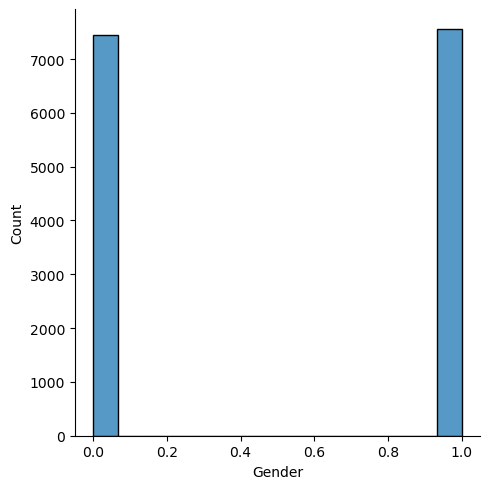

In [22]:
# distribution on Gender column
sns.displot(cal_exe_data['Gender'])

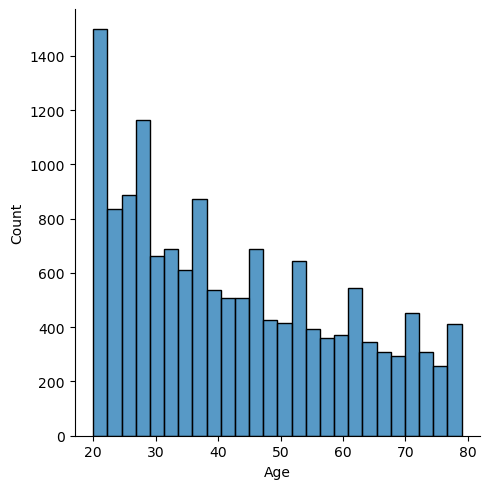

In [23]:
# distribution on Age column
sns.displot(cal_exe_data['Age'])

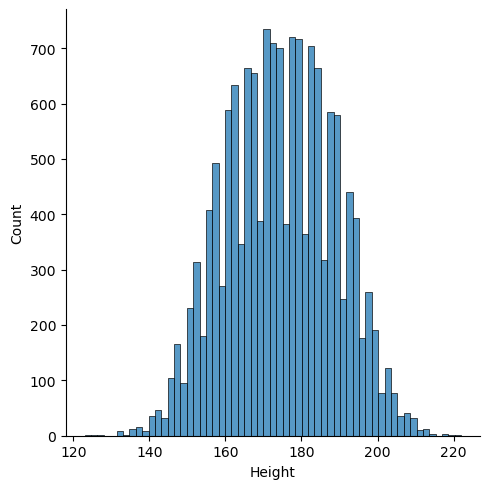

In [24]:
# distribution on Height column
sns.displot(cal_exe_data['Height'])

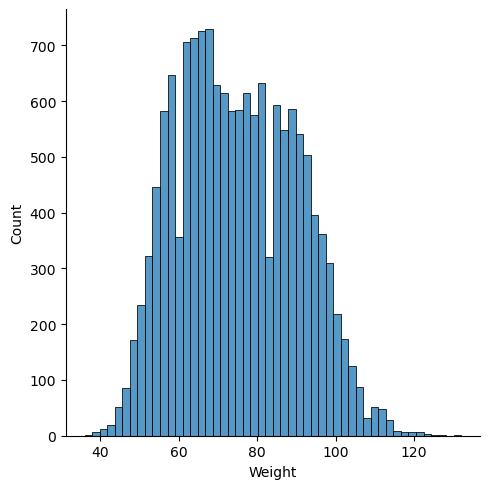

In [25]:
# distribution on Weight column
sns.displot(cal_exe_data['Weight'])

# Find the Correlation

In [26]:
correlation = cal_exe_data.corr()

<Axes: >

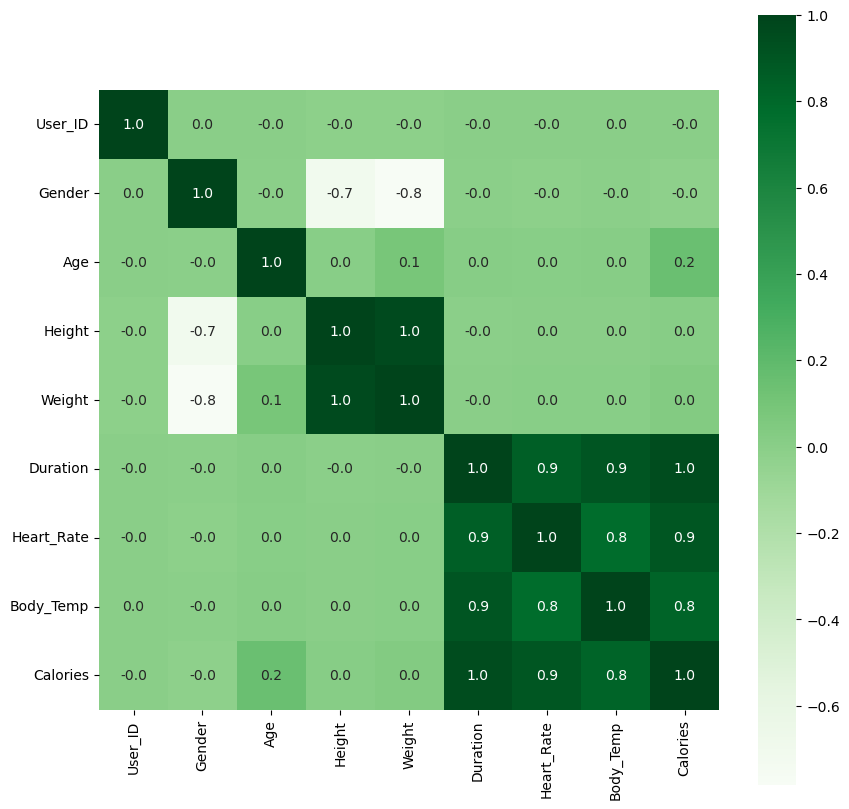

In [27]:
# heatmap
plt.figure(figsize=(10,10))
sns.heatmap(correlation, cbar=True, square=True, fmt='.1f', annot=True, cmap='Greens')

# Data Splitting

In [28]:
# separate the Features and the Target
X = cal_exe_data.drop(columns=['User_ID', 'Calories'], axis=1)
y = cal_exe_data['Calories']

In [29]:
print(X)

       Gender  Age  Height  Weight  Duration  Heart_Rate  Body_Temp
0           0   68   190.0    94.0      29.0       105.0       40.8
1           1   20   166.0    60.0      14.0        94.0       40.3
2           0   69   179.0    79.0       5.0        88.0       38.7
3           1   34   179.0    71.0      13.0       100.0       40.5
4           1   27   154.0    58.0      10.0        81.0       39.8
...       ...  ...     ...     ...       ...         ...        ...
14995       1   20   193.0    86.0      11.0        92.0       40.4
14996       1   27   165.0    65.0       6.0        85.0       39.2
14997       1   43   159.0    58.0      16.0        90.0       40.1
14998       0   78   193.0    97.0       2.0        84.0       38.3
14999       0   63   173.0    79.0      18.0        92.0       40.5

[15000 rows x 7 columns]


In [30]:
print(y)

0        231.0
1         66.0
2         26.0
3         71.0
4         35.0
         ...  
14995     45.0
14996     23.0
14997     75.0
14998     11.0
14999     98.0
Name: Calories, Length: 15000, dtype: float64


## Train Test Split

In [31]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [32]:
# shape of the train/test dataset
X.shape, y.shape, X_train.shape, X_test.shape, y_train.shape, y_test.shape

((15000, 7), (15000,), (10500, 7), (4500, 7), (10500,), (4500,))

# Model Training

In [33]:
# train the model
model = LogisticRegression()
# fit the model
model.fit(X_train, y_train)

/opt/miniconda3/envs/ml_env/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

# Model Prediction

### Training & Testing Dataset

In [34]:
# training data
train_pred = model.predict(X_train)
# testing_data
test_pred = model.predict(X_test)

In [35]:
# result
print("Training Data: ", train_pred)
print("Testing Data: ", test_pred)

Training Data:  [ 12.  91. 104. ...  38.  57.  65.]
Testing Data:  [182. 165.  48. ...  25. 141. 246.]


# Model Evaluation

## Training Data

In [36]:
mse_train = metrics.mean_squared_error(train_pred, y_train)
mae_train = metrics.mean_absolute_error(train_pred, y_train)
rmse_train = metrics.root_mean_squared_error(train_pred, y_train)
r2_train = metrics.r2_score(train_pred, y_train)

In [37]:
# result
print("Mean Squared Error : ", mse_train)
print("Mean Absolute Error :", mae_train)
print("Root Mean Squared Error :", rmse_train)
print("R2 Score :", r2_train)

Mean Squared Error :  956.1223809523809
Mean Absolute Error : 16.583142857142857
Root Mean Squared Error : 30.921228645582325
R2 Score : 0.7911630022663982


## Testing Data

In [38]:
mse_test = metrics.mean_squared_error(test_pred, y_test)
mae_test = metrics.mean_absolute_error(test_pred, y_test)
rmse_test = metrics.root_mean_squared_error(test_pred, y_test)
r2_test = metrics.r2_score(test_pred, y_test)

In [39]:
# result
print("Mean Squared Error : ", mse_test)
print("Mean Absolute Error :", mae_test)
print("Root Mean Squared Error :", rmse_test)
print("R2 Score :", r2_test)

Mean Squared Error :  1025.6275555555555
Mean Absolute Error : 17.489333333333335
Root Mean Squared Error : 32.025420458684934
R2 Score : 0.7772461687312721


# Predictive System

In [40]:
input_data = (0,69,179.0,79.0,5.0,88.0,38.7) # Low Calories
# input_data = (1,34,179.0,71.0,13.0,100.0,40.5) # High Calories

# convert the input data as a numpy array
input_data_as_array = np.asarray(input_data)

# convert input data into a numpy array
input_data_reshape = input_data_as_array.reshape(1,-1)

# prediction
prediction = model.predict(input_data_reshape)
print(prediction)

if(prediction[0] == 0):
    print('High Calories')
else:
    print('Low Calories')

[22.]
Low Calories


/opt/miniconda3/envs/ml_env/lib/python3.13/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


# Save the trained model

In [41]:
# load the pickle library
import pickle

In [42]:
# save the pickle file
filename = 'calorie_model.sav'
pickle.dump(model, open(filename, 'wb'))

In [43]:
# load the pickle file
loaded_model = pickle.load(open('calorie_model.sav', 'rb'))